<a href="https://colab.research.google.com/github/NayanaN27/CSCI611_Nayana_Nagarajappa/blob/main/project/Assignment_2/Nayana_Nagarajappa_Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import torch
print("Torch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

Torch version: 2.10.0+cu128
GPU available: True


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [9]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform_train
)

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform_test
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=128,
    shuffle=True
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=128,
    shuffle=False
)

print("Training samples:", len(trainset))
print("Test samples:", len(testset))


Training samples: 50000
Test samples: 10000


In [11]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = CNN().to(device)
print(model)

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 25

In [13]:
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(trainloader)
    train_losses.append(train_loss)

    # Validation
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    val_loss /= len(testloader)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.4f} "
          f"Val Loss: {val_loss:.4f}")


Epoch [1/25] Train Loss: 1.8376 Val Loss: 1.5675
Epoch [2/25] Train Loss: 1.4954 Val Loss: 1.2309
Epoch [3/25] Train Loss: 1.2734 Val Loss: 1.1127
Epoch [4/25] Train Loss: 1.1380 Val Loss: 0.9437
Epoch [5/25] Train Loss: 1.0305 Val Loss: 0.8594
Epoch [6/25] Train Loss: 0.9498 Val Loss: 0.8203
Epoch [7/25] Train Loss: 0.8837 Val Loss: 0.7509
Epoch [8/25] Train Loss: 0.8295 Val Loss: 0.7267
Epoch [9/25] Train Loss: 0.7866 Val Loss: 0.6725
Epoch [10/25] Train Loss: 0.7566 Val Loss: 0.6695
Epoch [11/25] Train Loss: 0.7229 Val Loss: 0.6361
Epoch [12/25] Train Loss: 0.7025 Val Loss: 0.6289
Epoch [13/25] Train Loss: 0.6743 Val Loss: 0.6031
Epoch [14/25] Train Loss: 0.6550 Val Loss: 0.6302
Epoch [15/25] Train Loss: 0.6389 Val Loss: 0.5890
Epoch [16/25] Train Loss: 0.6219 Val Loss: 0.6043
Epoch [17/25] Train Loss: 0.6103 Val Loss: 0.6103
Epoch [18/25] Train Loss: 0.5968 Val Loss: 0.5886
Epoch [19/25] Train Loss: 0.5821 Val Loss: 0.5489
Epoch [20/25] Train Loss: 0.5756 Val Loss: 0.5332
Epoch [21

In [14]:
correct = 0
total = 0

model.eval()
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Final Test Accuracy: {accuracy:.2f}%")


Final Test Accuracy: 82.39%


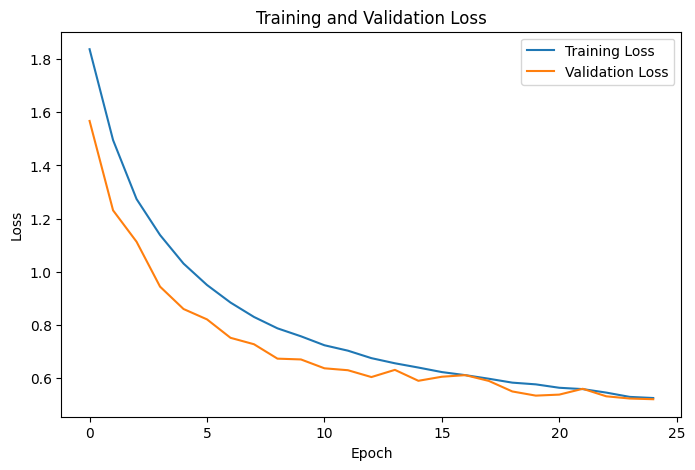

In [15]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.show()


In [16]:
import numpy as np

classes = trainset.classes

selected_images = []
selected_labels = []
used_classes = set()

for img, label in testset:
    if label not in used_classes:
        selected_images.append(img)
        selected_labels.append(label)
        used_classes.add(label)
    if len(selected_images) == 3:
        break

print("Selected classes:")
for label in selected_labels:
    print(classes[label])


Selected classes:
cat
ship
airplane


In [17]:
model.features[0]


Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

In [18]:
def visualize_feature_maps(image, label, model, num_maps=8):
    model.eval()

    image_batch = image.unsqueeze(0).to(device)

    first_conv = model.features[0]

    with torch.no_grad():
        feature_maps = first_conv(image_batch)

    feature_maps = feature_maps.squeeze(0).cpu()

    plt.figure(figsize=(18,5))

    # Unnormalize image
    img = image.permute(1,2,0).cpu().numpy()
    img = (img * 0.5) + 0.5

    plt.subplot(1, num_maps+1, 1)
    plt.imshow(img, interpolation='nearest')
    plt.title(f"Original\n{classes[label]}")
    plt.axis('off')

    for i in range(num_maps):
        plt.subplot(1, num_maps+1, i+2)
        plt.imshow(feature_maps[i], cmap='gray', interpolation='nearest')
        plt.title(f"Map {i}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()


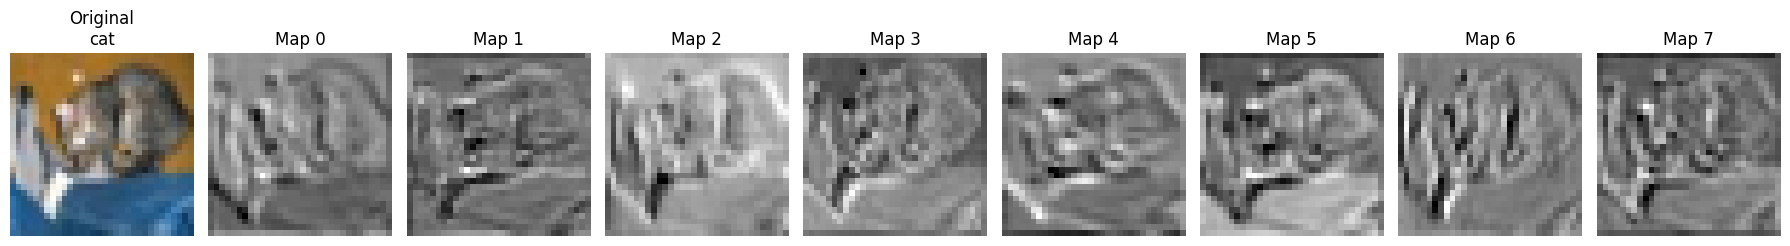

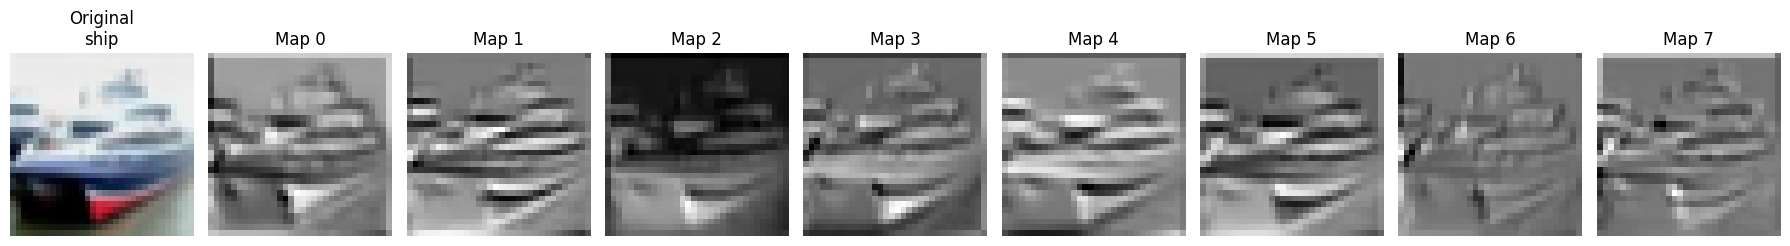

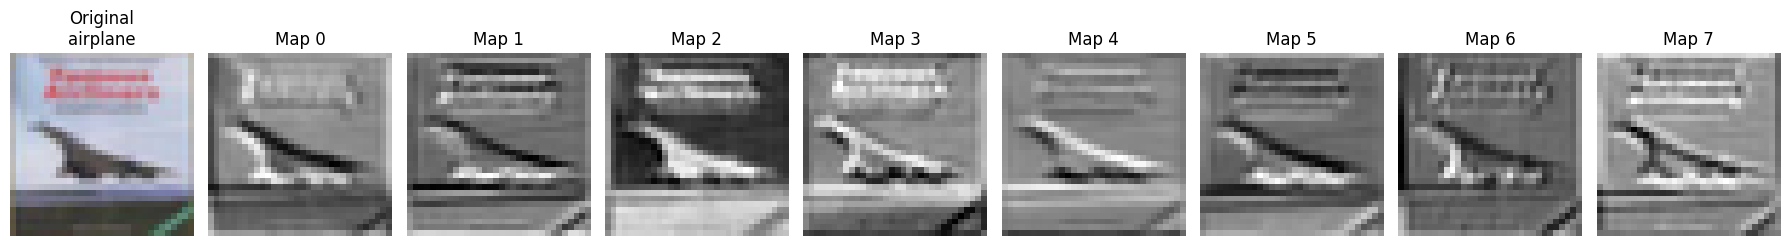

In [19]:
for img, label in zip(selected_images, selected_labels):
    visualize_feature_maps(img, label, model)


In [20]:
model.features[5]

Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

In [21]:
def get_filter_activations(model, layer_index, filter_index):
    model.eval()

    activations = []

    layer = model.features[layer_index]

    for img, label in testset:
        img_batch = img.unsqueeze(0).to(device)

        with torch.no_grad():
            x = img_batch
            for i in range(layer_index + 1):
                x = model.features[i](x)

            feature_map = x[0, filter_index]

            activation_value = feature_map.mean().item()

        activations.append((activation_value, img, label))

    activations.sort(key=lambda x: x[0], reverse=True)

    return activations


In [22]:
layer_index = 5
selected_filters = [0, 10, 20]


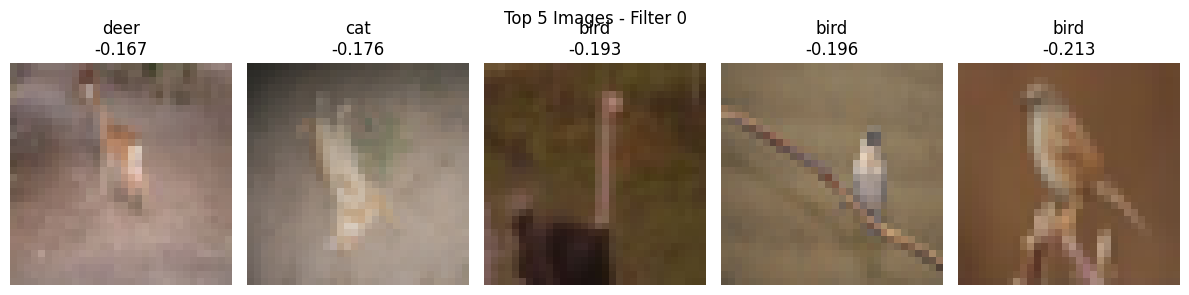

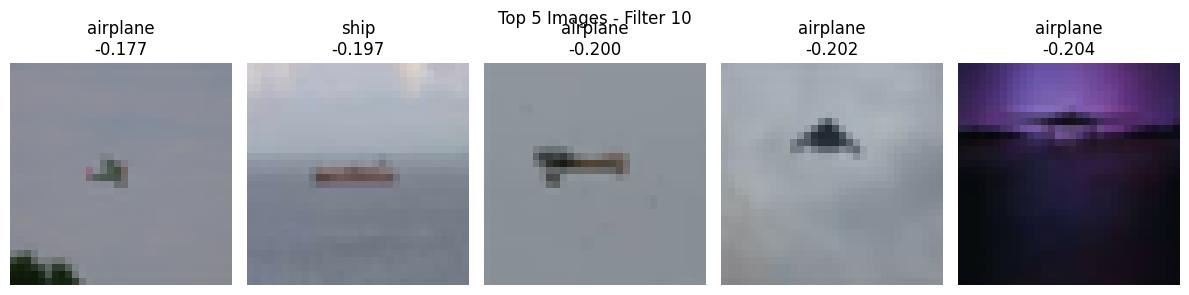

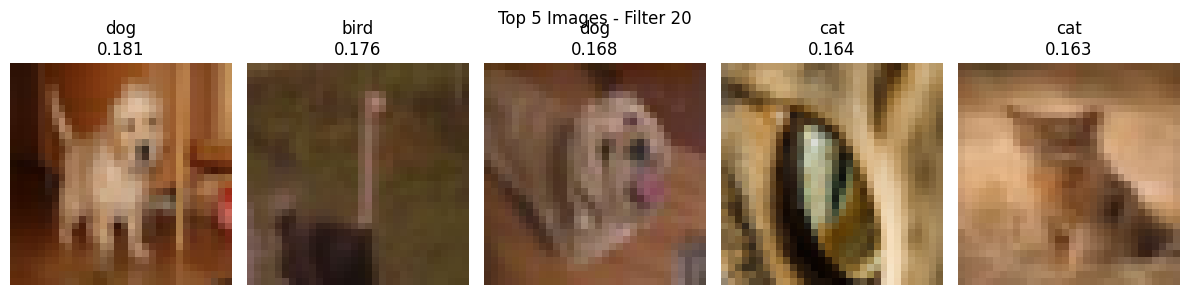

In [23]:
def visualize_top_images(filter_index):
    activations = get_filter_activations(model, layer_index, filter_index)

    top_images = activations[:5]

    plt.figure(figsize=(12,3))

    for i, (act, img, label) in enumerate(top_images):
        img_np = img.permute(1,2,0).cpu().numpy()
        img_np = (img_np * 0.5) + 0.5

        plt.subplot(1,5,i+1)
        plt.imshow(img_np)
        plt.title(f"{classes[label]}\n{act:.3f}")
        plt.axis('off')

    plt.suptitle(f"Top 5 Images - Filter {filter_index}")
    plt.tight_layout()
    plt.show()


for f in selected_filters:
    visualize_top_images(f)
